In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA

sns.set_style("whitegrid")

In [2]:
sales = pd.read_csv("/Users/nitin/Desktop/ba_final2/eVehicle-adoption-analytics/data/processed/ev_sales_clean.csv")
charging = pd.read_csv("/Users/nitin/Desktop/ba_final2/eVehicle-adoption-analytics/data/processed/charging_infrastructure_clean.csv")
iea = pd.read_csv("/Users/nitin/Desktop/ba_final2/eVehicle-adoption-analytics/data/processed/iea_ev_clean.csv")
stocks = pd.read_csv("/Users/nitin/Desktop/ba_final2/eVehicle-adoption-analytics/data/processed/stock_market_clean.csv")


In [3]:
sales.head()
charging.head()
iea.head()
stocks.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
0,2018-11-29 00:00:00-05:00,39.692784,40.064904,38.735195,39.037853,54917200,0.04,0.0,NVDA
1,2018-11-29 00:00:00-05:00,23.133333,23.166668,22.636667,22.744667,46210500,0.00,0.0,TSLA
2,2018-11-30 00:00:00-05:00,39.134605,40.650374,38.631003,40.543697,72956400,0.00,0.0,NVDA
3,2018-11-30 00:00:00-05:00,22.788668,23.440001,22.550667,23.365334,84436500,0.00,0.0,TSLA
4,2018-12-03 00:00:00-05:00,42.818602,43.334604,41.513699,42.183514,89080400,0.00,0.0,NVDA


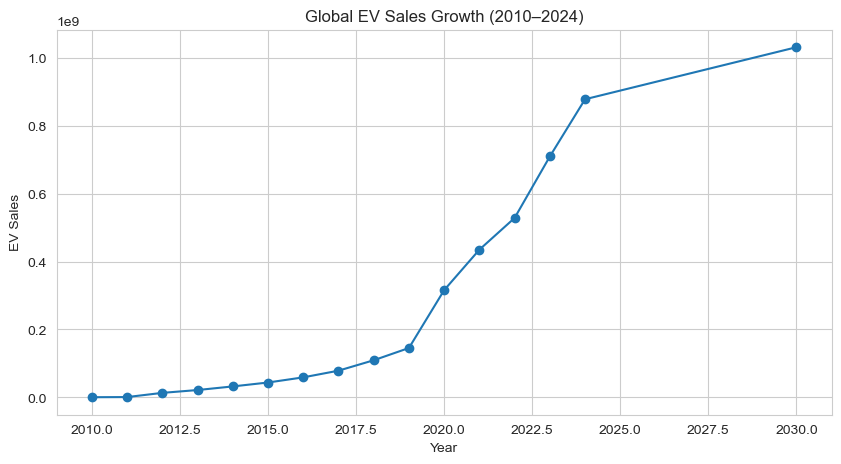

In [4]:
sales_year = sales.groupby("year")["ev_sales"].sum().reset_index()
plt.figure(figsize=(10,5))
plt.plot(
    sales_year["year"],
    sales_year["ev_sales"],
    marker="o"
)
plt.title("Global EV Sales Growth (2010–2024)")
plt.xlabel("Year")
plt.ylabel("EV Sales")
plt.grid(True)
plt.show()

In [5]:
country_map = {
    168: "USA",
    80: "China",
    87: "Germany",
    1: "India"
}
charging['country'] = charging['country'].map(country_map)

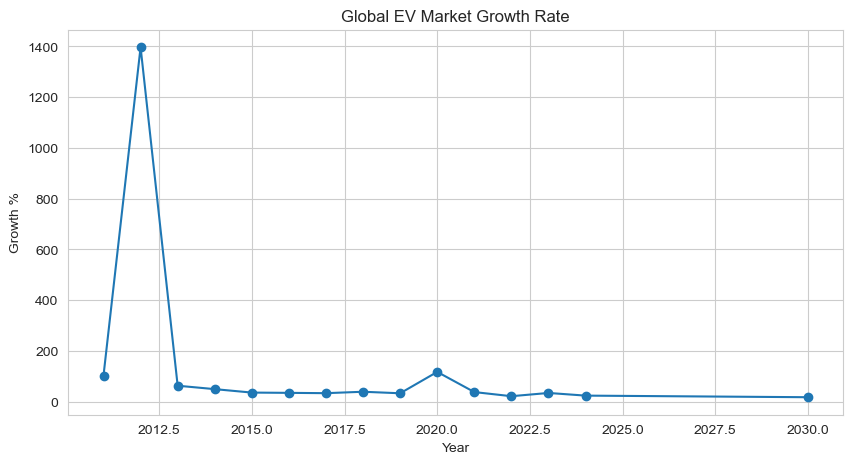

In [6]:
sales_year["growth_rate"] = sales_year["ev_sales"].pct_change()*100
plt.figure(figsize=(10,5))
plt.plot(
    sales_year["year"],
    sales_year["growth_rate"],
    marker="o"
)
plt.title("Global EV Market Growth Rate")
plt.xlabel("Year")
plt.ylabel("Growth %")
plt.grid(True)
plt.show()

<Figure size 800x600 with 0 Axes>

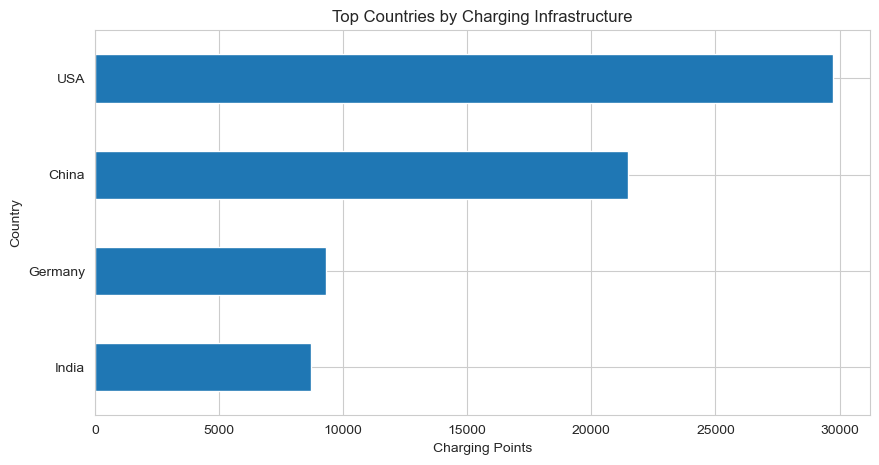

In [7]:
plt.figure(figsize=(8,6))
plt.figure(figsize=(10,5))
charging.groupby("country")["charging_points"].sum().sort_values().tail(10).plot(kind="barh")
plt.title("Top Countries by Charging Infrastructure")
plt.xlabel("Charging Points")
plt.ylabel("Country")
plt.show()

In [8]:
charging.columns

Index(['country', 'latitude', 'longitude', 'charging_points'], dtype='object')

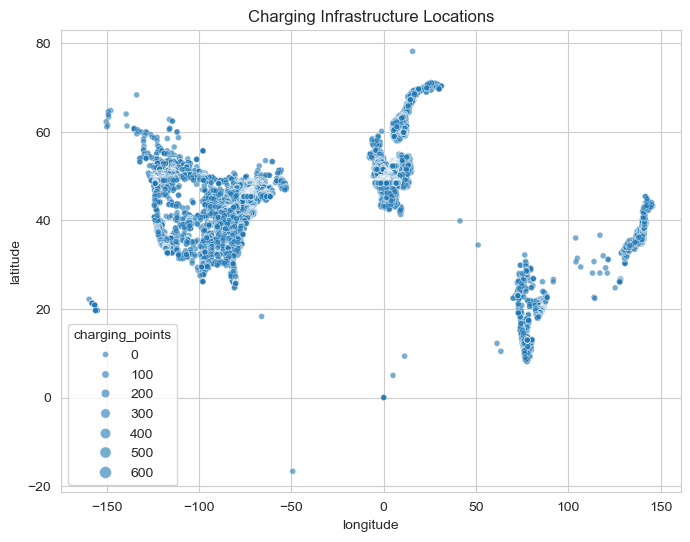

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="longitude",
    y="latitude",
    size="charging_points",
    data=charging,
    alpha=0.6
)
plt.title("Charging Infrastructure Locations")
plt.show()

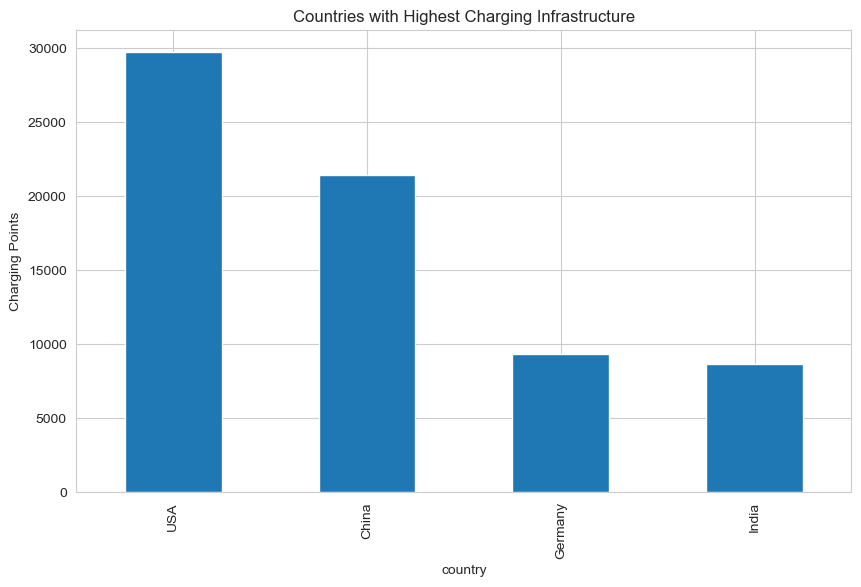

In [10]:
country_infra = charging.groupby("country")["charging_points"].sum()
plt.figure(figsize=(10,6))
country_infra.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Countries with Highest Charging Infrastructure")
plt.ylabel("Charging Points")
plt.show()

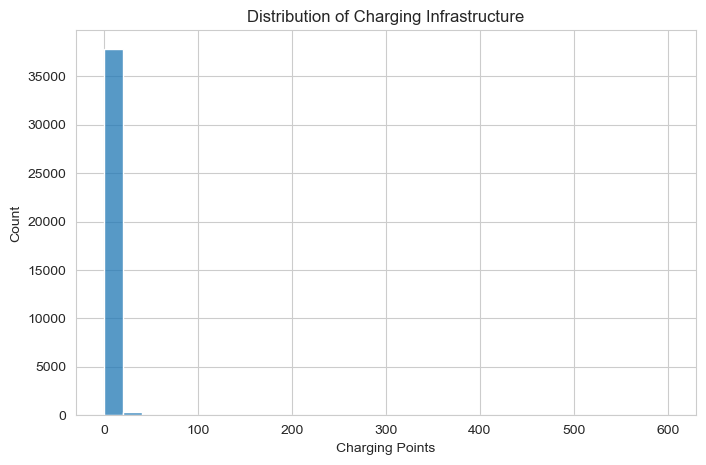

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(
    charging["charging_points"],
    bins=30
)
plt.title("Distribution of Charging Infrastructure")
plt.xlabel("Charging Points")
plt.show()

In [12]:
charging_country = charging.groupby("country", as_index=False)["charging_points"].sum()

In [13]:
merged = pd.merge(
    sales,
    charging,
    left_on="region_country",
    right_on="country"
)

In [14]:
merged.head()

,region_country,year,ev_sales,country,latitude,longitude,charging_points
0,China,2030,91000000.0,China,48.927517,2.548519,7
1,China,2030,91000000.0,China,45.146819,1.480304,9
2,China,2030,91000000.0,China,44.864081,1.041895,4
3,China,2030,91000000.0,China,44.834830,0.478508,4
4,China,2030,91000000.0,China,44.833041,0.477847,2


In [15]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [17]:
data = merged[['charging_points','ev_sales']]
X = data[['charging_points']]
y = data['ev_sales']
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test,pred))

R2 Score: 4.4425327415442695e-05


In [19]:
merged = pd.merge(
    sales,
    charging_country,
    left_on="region_country",
    right_on="country"
)

In [20]:
charging_country = charging.groupby("country", as_index=False)["charging_points"].sum()

In [21]:
merged_country = merged.groupby("country").agg({
    "charging_points":"mean",
    "ev_sales":"mean"
}).reset_index()

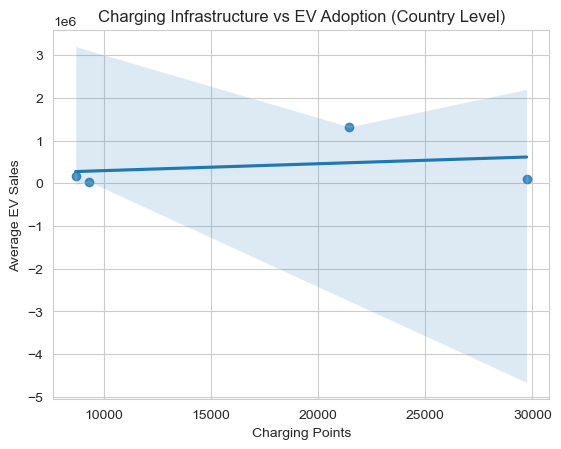

In [22]:
sns.regplot(
    x="charging_points",
    y="ev_sales",
    data=merged_country
)

plt.title("Charging Infrastructure vs EV Adoption (Country Level)")
plt.xlabel("Charging Points")
plt.ylabel("Average EV Sales")

plt.show()

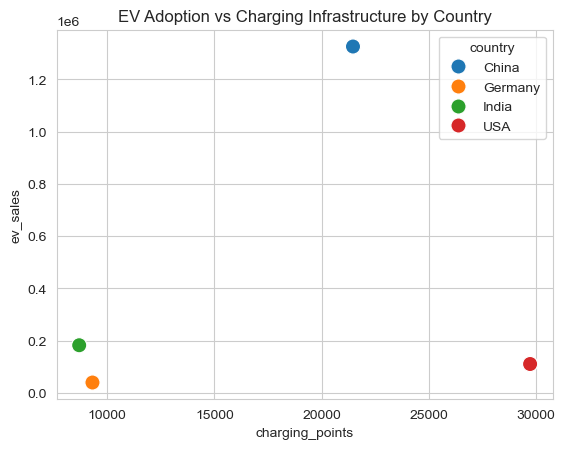

In [23]:
sns.scatterplot(
    x="charging_points",
    y="ev_sales",
    hue="country",
    data=merged_country,
    s=120
)
plt.title("EV Adoption vs Charging Infrastructure by Country")
plt.show()